## RFF Data Task

### 1. Creating a ZCTA-year level panel dataset.

In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt #importing relevant packages

# read in necessary files, add them to a list
naicnames = os.listdir('raw_data/naic')
naicnames.remove('Data_Dictionary.xlsx')
naicdata = [pd.read_excel('raw_data/naic/' + x) for x in naicnames]

# create panel dataframe by concatenating vertically
naicpanel = pd.concat(naicdata)

# sort and extract relevant variables
naicpanel = naicpanel.sort_values('Year')
naicpanel = naicpanel[['ZIP Code', 'Year', 'Nonrenewal Rate']]

naicpanel

,ZIP Code,Year,Nonrenewal Rate
3,89439,2018,0.002994
4,90001,2018,0.006425
5,90002,2018,0.004516
6,90003,2018,0.007502
7,90004,2018,0.006017
...,...,...,...
59,90201,2022,0.010859
58,90094,2022,0.003185
0,89019,2022,0.008475
57,90077,2022,0.048355


### 2.  Merging NHGIS data

In [2]:
# read in NHGIS data, filter out relevant columns
nhgis = pd.read_csv('raw_data/nhgis/nhgis0021_ds258_2020_zcta.csv')
nhgis = nhgis[['ZCTAA', 'U9V001']]

# left join NAIC and NHGIS data, preserve all data from NAIC and repeat values from NHGIS
naicmerged = naicpanel.merge(nhgis, how = 'left', left_on = 'ZIP Code', right_on = 'ZCTAA')

# format dataset, rename columns to be descriptive
naicmerged = naicmerged.drop('ZCTAA', axis=1).rename(columns={'U9V001':'Total Housing Units'})
naicmerged

,ZIP Code,Year,Nonrenewal Rate,Total Housing Units
0,89439,2018,0.002994,1051
1,90001,2018,0.006425,13820
2,90002,2018,0.004516,13036
3,90003,2018,0.007502,18244
4,90004,2018,0.006017,24944
...,...,...,...,...
7775,90201,2022,0.010859,25501
7776,90094,2022,0.003185,7000
7777,89019,2022,0.008475,1766
7778,90077,2022,0.048355,3823


### 3. Merging Counties

In [3]:
# read in census data from TXT file, use pipe as delimiter
census = pd.read_csv('raw_data/census/tab20_zcta520_county20_natl.txt', delimiter = '|')

# fill na's, filter relevant columns, format datatypes
census = census.fillna(0)
census = census[['AREALAND_ZCTA5_20', 'GEOID_ZCTA5_20', 'AREALAND_PART', 'NAMELSAD_COUNTY_20']]
census['GEOID_ZCTA5_20'] = census['GEOID_ZCTA5_20'].astype('int64')

# merge census data into frame, ensure that multiple counties/ZCTA are included, reformat data 
zctacounty = naicmerged.merge(census, how = 'inner', left_on = 'ZIP Code', right_on = 'GEOID_ZCTA5_20')
zctacounty = zctacounty.drop('GEOID_ZCTA5_20', axis = 1).rename(columns = {'AREALAND_ZCTA5_20':'ZCTA Area', 
                                                                           'AREALAND_PART': 'ZCTA Partial Area',
                                                                           'NAMELSAD_COUNTY_20': 'County Name'})

zctacounty[zctacounty['ZIP Code'] == 93252] # check that frame retains multiple counties for each zip code

,ZIP Code,Year,Nonrenewal Rate,Total Housing Units,ZCTA Area,ZCTA Partial Area,County Name
717,93252,2018,0.007042,689,1.156539e+09,210327833,Kern County
718,93252,2018,0.007042,689,1.156539e+09,71298452,San Luis Obispo County
719,93252,2018,0.007042,689,1.156539e+09,105856391,Santa Barbara County
720,93252,2018,0.007042,689,1.156539e+09,769056802,Ventura County
2449,93252,2019,0.020000,689,1.156539e+09,210327833,Kern County
2450,93252,2019,0.020000,689,1.156539e+09,71298452,San Luis Obispo County
2451,93252,2019,0.020000,689,1.156539e+09,105856391,Santa Barbara County
2452,93252,2019,0.020000,689,1.156539e+09,769056802,Ventura County
4554,93252,2020,0.018634,689,1.156539e+09,210327833,Kern County
4555,93252,2020,0.018634,689,1.156539e+09,71298452,San Luis Obispo County


### 4. Partial Housing Measure 

In [4]:
# Ensure that the partial area adds up to the total area of ZCTA, meaning we can use this for
# the proportional separation measure
zgrp = zctacounty.groupby(['ZIP Code', 'Year']).agg({'ZCTA Area':'max', 'ZCTA Partial Area':'sum'})
zgrp['Validator'] = zgrp['ZCTA Area'] == zgrp['ZCTA Partial Area']
zgrp['Validator'].unique()

array([ True])

In [5]:
# the partial housing measure calculates the land share of each county, and calculates the amount of units
# for each ZCTA - County - Year entry
zctacounty['Land Share'] = zctacounty['ZCTA Partial Area'] / zctacounty['ZCTA Area']
zctacounty['Housing Units'] = zctacounty['Land Share'] * zctacounty['Total Housing Units']
zctacounty

,ZIP Code,Year,Nonrenewal Rate,Total Housing Units,ZCTA Area,ZCTA Partial Area,County Name,Land Share,Housing Units
0,89439,2018,0.002994,1051,4.211596e+07,10808119,Sierra County,0.256628,269.715614
1,89439,2018,0.002994,1051,4.211596e+07,31307845,Washoe County,0.743372,781.284386
2,90001,2018,0.006425,13820,8.495419e+06,8495419,Los Angeles County,1.000000,13820.000000
3,90002,2018,0.004516,13036,7.750658e+06,7750658,Los Angeles County,1.000000,13036.000000
4,90003,2018,0.007502,18244,9.389487e+06,9389487,Los Angeles County,1.000000,18244.000000
...,...,...,...,...,...,...,...,...,...
8690,89019,2022,0.008475,1766,1.293877e+09,11635487,Inyo County,0.008993,15.881156
8691,89019,2022,0.008475,1766,1.293877e+09,278510420,San Bernardino County,0.215253,380.136005
8692,89019,2022,0.008475,1766,1.293877e+09,1003731534,Clark County,0.775755,1369.982838
8693,90077,2022,0.048355,3823,1.880758e+07,18807577,Los Angeles County,1.000000,3823.000000


### 5. County-Year Level Data

In [6]:
# To calculate weighted average, take sum of weights * variables and divide by sum of weights

# calculate the individual products
zctacounty['Weighted'] = zctacounty['Housing Units'] * zctacounty ['Nonrenewal Rate']

# sum up the numerator and denominator in the formula
countygrp =  zctacounty.groupby(['County Name', 'Year'])[['Weighted', 'Housing Units']].sum()

# divide out to get county-year level data with weighted average nonrenewal rates 
countygrp['Mean Weighted Nonrenewal'] =  countygrp['Weighted']/countygrp['Housing Units']
countygrp = countygrp.reset_index()
countygrp

,County Name,Year,Weighted,Housing Units,Mean Weighted Nonrenewal
0,Alameda County,2018,2304.200489,604987.023355,0.003809
1,Alameda County,2019,4361.512457,604987.023355,0.007209
2,Alameda County,2020,4632.223070,604987.023355,0.007657
3,Alameda County,2021,4132.844500,604987.023355,0.006831
4,Alameda County,2022,5347.504746,604987.023355,0.008839
...,...,...,...,...,...
300,Yuba County,2018,207.508072,28211.747354,0.007355
301,Yuba County,2019,615.307941,28211.747354,0.021810
302,Yuba County,2020,588.883150,28211.747354,0.020874
303,Yuba County,2021,349.480619,28211.747354,0.012388


### 6. Merge with NRI Data

In [7]:
# read in NRI data
nri = pd.read_csv('raw_data/nri/NRI_California.csv')

# create a new column to match formatting of primary key from previous data
nri ['County Name'] =  nri['COUNTY'] + ' ' + nri['COUNTYTYPE']

# merge and filter dataset
final = countygrp.merge(nri, on = 'County Name')
final = final[['County Name', 'Year', 'Mean Weighted Nonrenewal', 'WFIR_EALB', 'WFIR_EALT']]
finaltoprint = final.rename(columns = {'WFIR_EALB':'Expected Annual Loss - Buildings', 'WFIR_EALT':'Expected Annual Loss - Total'})

In [8]:
finaltoprint

,County Name,Year,Mean Weighted Nonrenewal,Expected Annual Loss - Buildings,Expected Annual Loss - Total
0,Alameda County,2018,0.003809,6.611995e+06,6.731674e+06
1,Alameda County,2019,0.007209,6.611995e+06,6.731674e+06
2,Alameda County,2020,0.007657,6.611995e+06,6.731674e+06
3,Alameda County,2021,0.006831,6.611995e+06,6.731674e+06
4,Alameda County,2022,0.008839,6.611995e+06,6.731674e+06
...,...,...,...,...,...
285,Yuba County,2018,0.007355,3.198556e+06,3.211650e+06
286,Yuba County,2019,0.021810,3.198556e+06,3.211650e+06
287,Yuba County,2020,0.020874,3.198556e+06,3.211650e+06
288,Yuba County,2021,0.012388,3.198556e+06,3.211650e+06


In [9]:
finaltoprint.to_csv('rff_output_data.csv', index=False)

In [10]:
final.isna().sum()

County Name                 0
Year                        0
Mean Weighted Nonrenewal    0
WFIR_EALB                   0
WFIR_EALT                   0
dtype: int64

In [11]:
# One thing I noticed was the amount of rows dropped after merging with the NRI data. After some checks,
# it turns out that 3 counties in the ZCTA dataset do not appear in the NRI data, as these three are in Nevada.
set1 = set(nri['County Name'])
set2 = set(countygrp['County Name'])

only_in_nri = set1 - set2
only_in_countygrp = set2 - set1

print(only_in_nri, only_in_countygrp)

set() {'Washoe County', 'Clark County', 'Nye County'}


### 7. Plotting Changes across time

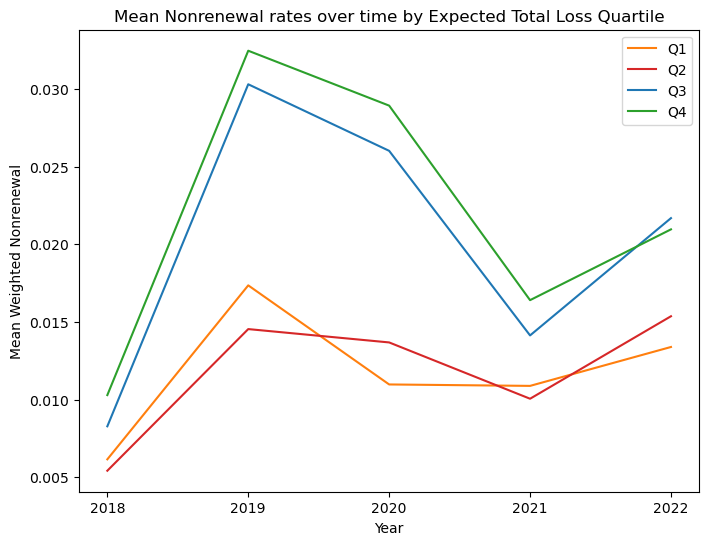

In [12]:
# set quartiles of expected total loss
q1 = final['WFIR_EALT'].quantile(0.25)
q3 = final['WFIR_EALT'].quantile(0.75)
median = final['WFIR_EALT'].quantile(0.5)

# label each row with a quartile
def label_quartile(value):
    if value <= q1:
        return 'Q1'
    elif value <= median:
        return 'Q2'
    elif value <= q3:
        return 'Q3'
    else:
        return 'Q4'

final['Quartile'] = final['WFIR_EALT'].apply(label_quartile)

# create a lineplot
fig, ax = plt.subplots(figsize=(8, 6))

sns.lineplot(final, x = 'Year', y = 'Mean Weighted Nonrenewal', hue='Quartile', errorbar=None, err_style = 'band')

ax.set_xticks([2018, 2019, 2020, 2021, 2022])
handles, labels = ax.get_legend_handles_labels()

order = [1, 3, 0, 2] 
ax.legend([handles[i] for i in order], [labels[i] for i in order])
ax.set_title('Mean Nonrenewal rates over time by Expected Total Loss Quartile')

plt.show() 

This graph looks at the change in mean nonrenewal rates over time, with each line representing the average nonrenewal rate within a certain quartile of expected total loss. This graph to me helped understand the relationship between the expected loss and nonrenewal, and establishes some preliminary evidence that high or above average expected total loss leads to higher non renewal rates. Within the above and below average segments, there isn't too much difference, but there is separation around the average. This is definitely not causal, but may help recontextualize the approach. Instead of looking at the direct relationship between expected loss and nonrenewal, it might help to look at whether having above or below median expected loss changes nonrenewal.

### 8. Basic RDD

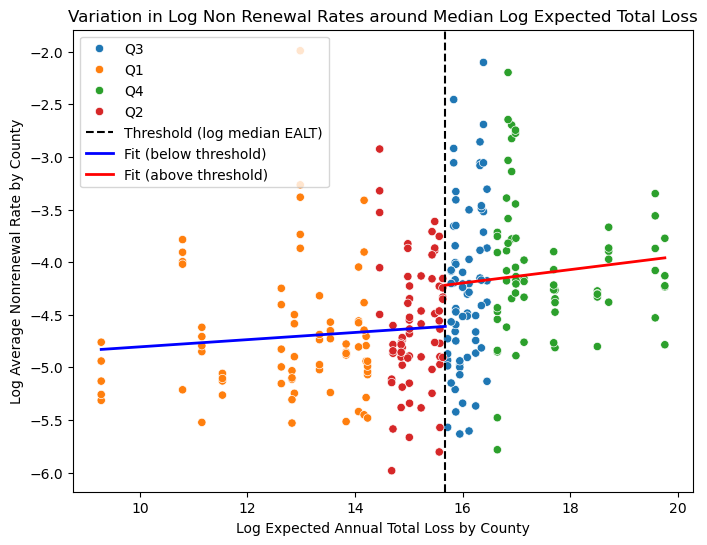

Below threshold — slope: 0.0342, intercept: -5.1475, R²: 0.0081, p: 0.2820, SE: 0.0317
Above threshold — slope: 0.0636, intercept: -5.2167, R²: 0.0093, p: 0.2488, SE: 0.0549


In [14]:
from scipy import stats

# set the RDD threshold as the log of the median EALT
threshold = np.log(final['WFIR_EALT'].median())

# transform the two columns to logs
final['log ealt'] = np.log(final['WFIR_EALT'])
final['log nonrenewal'] = np.log(final['Mean Weighted Nonrenewal'])

# filter the datapoints based on the threshold
below = final[final['log ealt'] < threshold]
above = final[final['log ealt'] >= threshold]

# fit lines of best fit on each side
slope_below, intercept_below, r_below, p_below, se_below = stats.linregress(below['log ealt'], below['log nonrenewal'])
slope_above, intercept_above, r_above, p_above, se_above = stats.linregress(above['log ealt'], above['log nonrenewal'])

# create the independent variable arrays to plot lines
x_below = np.linspace(below['log ealt'].min(), threshold, 100)
x_above = np.linspace(threshold, above['log ealt'].max(), 100)

# plot the scatter, lines, and threshold
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(final, x='log ealt', y='log nonrenewal', hue='Quartile', ax=ax)

# threshold line
ax.axvline(x=threshold, color='black', linestyle='--', label='Threshold (log median EALT)')

# lines of best fit
ax.plot(x_below, intercept_below + slope_below * x_below, color='blue', linewidth=2, label='Fit (below threshold)')
ax.plot(x_above, intercept_above + slope_above * x_above, color='red', linewidth=2, label='Fit (above threshold)')

ax.set_title('Variation in Log Non Renewal Rates around Median Log Expected Total Loss')
ax.set_xlabel('Log Expected Annual Total Loss by County')
ax.set_ylabel('Log Average Nonrenewal Rate by County')

ax.legend()
plt.show()

print(f"Below threshold — slope: {slope_below:.4f}, intercept: {intercept_below:.4f}, R²: {r_below**2:.4f}, p: {p_below:.4f}, SE: {se_below:.4f}")
print(f"Above threshold — slope: {slope_above:.4f}, intercept: {intercept_above:.4f}, R²: {r_above**2:.4f}, p: {p_above:.4f}, SE: {se_above:.4f}")

In this visualization, I wanted to look at the idea from the graph earlier, specifically investigating how nonrenewal rates change around the cutoff of the median. I transformed the data to logs to make it easier to interpret and understand visually, and to control for very large entries in both series. I then plotted a regression discontinuity, with the cutoff being the median, the running variable as log EALT, and the dependent variable as the log nonrenewal rate. The lines before and after the cutoff don't have much explanatory power, as evidenced by the p-values and R^2's, but the split around the cutoff seems to be both statistically and economically significant (the SE's are very small). Then, while not causal, it does provide some evidence that being in a county above the median expected loss increases the rates of nonrenewal relative to the counties below the median.